### Import Libraries

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_excel('../data/sales_clean.xlsx')

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df.head(10)

,order_id,total_qty,total_weight_gr,total_returned_qty,total_discount,product_categories,num_product_categories,order_status,cancellation,shipping_option,payment_method,city,province,shipping_cost,estimated_shipping_cost_discount,total_payment,estimated_shipping_cost,order_time,source_file,month_period,day_of_week,profit,order_segment,discount_segment
0,ORD_0000001,2,2000,0,0,Celengan,1,Selesai,Not Cancelled,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15:00,AprilSales2024.xlsx,2024-04,Monday,38300,Small,WithOut Discount
1,ORD_0000002,1,500,0,0,Celengan,1,Selesai,Not Cancelled,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47:00,AprilSales2024.xlsx,2024-04,Monday,18576,Single,WithOut Discount
2,ORD_0000003,1,500,0,0,Celengan,1,Selesai,Not Cancelled,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KABUPATEN BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25:00,AprilSales2024.xlsx,2024-04,Monday,7069,Single,WithOut Discount
3,ORD_0000004,2,400,0,0,Mangkok Sambal / Saus,1,Selesai,Not Cancelled,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41:00,AprilSales2024.xlsx,2024-04,Monday,32200,Small,WithOut Discount
4,ORD_0000005,3,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12:00,AprilSales2024.xlsx,2024-04,Monday,0,Small,WithOut Discount
5,ORD_0000006,2,1000,0,0,Celengan,1,Selesai,Not Cancelled,Hemat Kargo-SPX Hemat,SPayLater,KABUPATEN BANDUNG,JAWA BARAT,0,10000,40996,10000,2024-04-01 07:09:00,AprilSales2024.xlsx,2024-04,Monday,40996,Small,WithOut Discount
6,ORD_0000007,1,1700,0,0,Nampan / Tray,1,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,SPayLater,KOTA TANGERANG,BANTEN,0,0,0,16000,2024-04-01 07:23:00,AprilSales2024.xlsx,2024-04,Monday,0,Single,WithOut Discount
7,ORD_0000008,1,500,0,0,Celengan,1,Selesai,Not Cancelled,Hemat Kargo-SPX Hemat,Online Payment,KABUPATEN BOGOR,JAWA BARAT,0,8000,18280,8000,2024-04-01 07:33:00,AprilSales2024.xlsx,2024-04,Monday,18280,Single,WithOut Discount
8,ORD_0000009,1,500,0,0,Celengan,1,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-J&T Economy,Online Payment,KABUPATEN GARUT,JAWA BARAT,0,0,0,16500,2024-04-01 07:56:00,AprilSales2024.xlsx,2024-04,Monday,0,Single,WithOut Discount
9,ORD_0000010,6,12900,0,0,"Aksesoris Mandi, Celengan, Keranjang",3,Selesai,Not Cancelled,Hemat Kargo-SPX Hemat,Online Payment,KABUPATEN TEGAL,JAWA TENGAH,13000,20000,92800,33000,2024-04-01 08:27:00,AprilSales2024.xlsx,2024-04,Monday,79800,Medium,WithOut Discount


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20848 entries, 0 to 20847
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   order_id                          20848 non-null  object        
 1   total_qty                         20848 non-null  int64         
 2   total_weight_gr                   20848 non-null  int64         
 3   total_returned_qty                20848 non-null  int64         
 4   total_discount                    20848 non-null  int64         
 5   product_categories                20848 non-null  object        
 6   num_product_categories            20848 non-null  int64         
 7   order_status                      20848 non-null  object        
 8   cancellation                      20848 non-null  object        
 9   shipping_option                   20848 non-null  object        
 10  payment_method                    20848 non-nu

In [7]:
# ubah jadi category agar mengurangi memori
for col in ['order_status', 'cancellation', 'shipping_option', 'payment_method', 'city', 'province', 'source_file', 'month_period', 'day_of_week', 'order_segment', 'discount_segment']:
    df[col]= df[col].astype('category')

### Exploratory Data Analysis (EDA)

#### Pertanyaan Dasar (Univariate Analysis)

In [8]:
# 1. Berapa total penjualan
print(f"Total penjualan: Rp {df['total_payment'].sum():,}")

# 2. Rata-rata transaksi
print(f"Rata-rata Transaksi: Rp {df['total_payment'].mean():,}")

# 3. Berapa total profit
print(f"Total profit: Rp {df['profit'].sum():,}")

Total penjualan: Rp 1,056,651,631
Rata-rata Transaksi: Rp 50,683.59703568688
Total profit: Rp 969,298,706


In [9]:
# 4. Jumlah pesanan per status

conditions = [
    (df['order_status'] == 'Selesai') & (df['total_returned_qty'] == 0),  # Selesai
    (df['order_status'] == 'Selesai') & (df['total_returned_qty'] > 0),   # Dikembalikan
    (df['order_status'] == 'Batal')                                        # Batal
]
categories = ['Selesai', 'Dikembalikan', 'Batal']

# Hitung jumlah untuk setiap kondisi
for i, (condition, category) in enumerate(zip(conditions, categories)):
    count = df[condition].shape[0]
    percentage = (count / len(df)) * 100
    print(f"{category:15} : {count:>6,} orders ({percentage:>5.1f}%)")

# Total
print("-"*50)
print(f"{'Total':15} : {len(df):>6,} orders (100.0%)")

Selesai         : 17,861 orders ( 85.7%)
Dikembalikan    :    157 orders (  0.8%)
Batal           :  2,830 orders ( 13.6%)
--------------------------------------------------
Total           : 20,848 orders (100.0%)


In [10]:
# 5. Cancellation
df.query("cancellation != 'Not Cancelled'")['cancellation'].value_counts()

Dibatalkan oleh Pembeli. Alasan: Lainnya/ berubah pikiran                                                                                             662
Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan yang Ada                                                                                                558
Dibatalkan secara otomatis oleh sistem. Alasan: Pesanan belum dibayar                                                                                 447
Dibatalkan oleh Pembeli. Alasan: Need to change delivery address                                                                                      306
Dibatalkan secara otomatis oleh sistem. Alasan: Pengiriman gagal                                                                                      255
Dibatalkan oleh Pembeli. Alasan: Perlu mengubah pesanan                                                                                               113
Dibatalkan secara otomatis oleh sistem. Alasan: Penjual gagal mengirimkan pe

In [11]:
# 5. 20 produk dengan jumlah pesanan terbanyak
df.groupby(['product_categories'])['total_qty'].sum().sort_values(ascending= False).head(20)

product_categories
Nampan / Tray             9942
Mangkok Sambal / Saus     8208
Celengan                  8206
Aksesoris Pintu           4523
Lunch Box / Rantang       3290
Seal / Baut / Roof        2125
Baskom / Mangkok Besar    1461
Keranjang                 1143
Piring                     895
Other                      839
Botol / Gelas / Mug        810
Tempat Nasi                637
Rak / Rak Serbaguna        626
Aksesoris ID Card          413
Saringan / Strainer        399
Peralatan Makan            398
Aksesoris Mandi            276
Teko / Jug                 262
Toples / Sealware          257
Pisau / Alat Potong        246
Name: total_qty, dtype: int64

#### Pertanyaan Tren (Time Series Analysis)

In [12]:
# 1. Tren penjualan per bulan
monthly_sales = df.groupby(['month_period'])['total_payment'].sum().reset_index()
monthly_sales

,month_period,total_payment
0,2023-12,23850125
1,2024-01,24492481
2,2024-02,21141376
3,2024-03,30259734
4,2024-04,21260662
5,2024-05,35530574
6,2024-06,32465925
7,2024-07,63791545
8,2024-08,65939126
9,2024-09,71193097


In [13]:
# 2. Hari dengan penjualan tertinggi
df.groupby('day_of_week')['total_payment'].sum().sort_values(ascending= False)

day_of_week
Monday       175432592
Wednesday    164997839
Tuesday      153408308
Friday       145184500
Thursday     143849158
Sunday       141673886
Saturday     132105348
Name: total_payment, dtype: int64

In [14]:
# 3. 10 kota dengan penjualan tertinggi
df.groupby('province')['total_payment'].sum().sort_values(ascending= False)

province
JAWA BARAT                        276992073
BANTEN                            177861752
DKI JAKARTA                       135164841
JAWA TENGAH                       100114044
JAWA TIMUR                         95478924
SUMATERA SELATAN                   40909428
LAMPUNG                            22028652
BALI                               21951090
SUMATERA UTARA                     19783218
SULAWESI SELATAN                   19680129
JAMBI                              15651007
RIAU                               15011507
NUSA TENGGARA BARAT (NTB)          13047395
KALIMANTAN BARAT                   12360930
SUMATERA BARAT                     11217328
KALIMANTAN SELATAN                 10075885
KALIMANTAN TIMUR                    9446377
DI YOGYAKARTA                       9422267
KALIMANTAN TENGAH                   6949690
BENGKULU                            6576117
BANGKA BELITUNG                     6328579
NANGGROE ACEH DARUSSALAM (NAD)      5936568
SULAWESI TENGGARA      

In [15]:
# 4. 10 kota dengan penjualan tertinggi
df.groupby('city')['total_payment'].sum().sort_values(ascending= False).head(10)

city
KABUPATEN TANGERANG       61557031
KABUPATEN BOGOR           58698901
KOTA TANGERANG            46541239
KOTA JAKARTA BARAT        43381103
KOTA TANGERANG SELATAN    36650441
KOTA JAKARTA SELATAN      34603898
KOTA DEPOK                29457272
KOTA PALEMBANG            26799136
KABUPATEN BANYUMAS        26397240
KABUPATEN BEKASI          25187473
Name: total_payment, dtype: int64

### Data Visualization

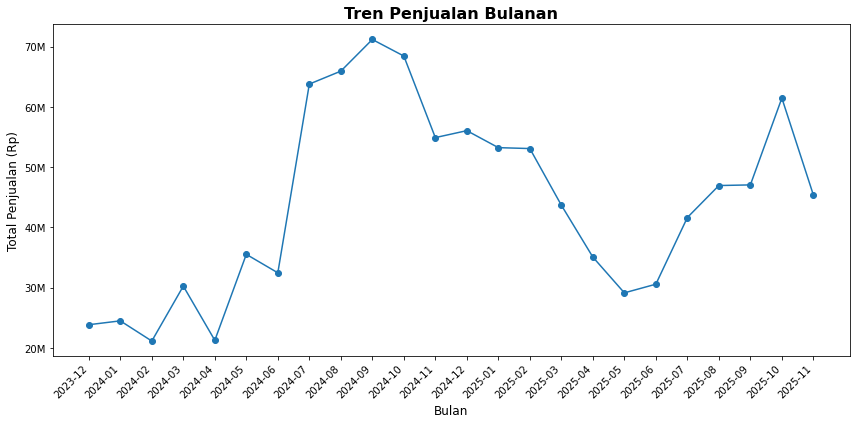

In [16]:
# 1. Tren penjualan per bulan (line chart)
plt.figure(figsize=(12,6))

monthly_sales = df.groupby('month_period')['total_payment'].sum()
ax = monthly_sales.plot(kind='line', marker='o')

ax.yaxis.set_major_formatter(lambda x, p: f'{int(x/1e6)}M')

ax.set_xticks(range(len(monthly_sales.index)))  # Set semua posisi
ax.set_xticklabels(monthly_sales.index, rotation=45, ha='right')  # Label semua bulan

plt.title('Tren Penjualan Bulanan', fontsize=16, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Penjualan (Rp)', fontsize=12)
plt.tight_layout() 
plt.show()

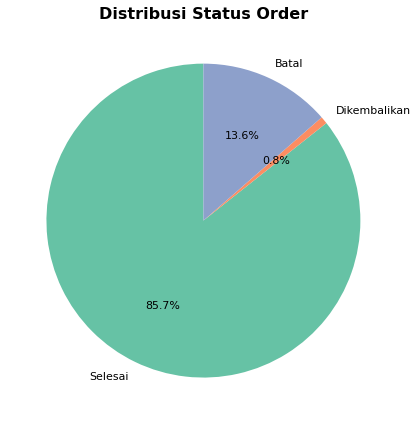

In [17]:
# 2. Jumlah Status order (line chart)
plt.figure(figsize=(12,6))

# Buat kondisi untuk 3 kategori
conditions = [
    (df['order_status'] == 'Selesai') & (df['total_returned_qty'] == 0),  # Selesai
    (df['order_status'] == 'Selesai') & (df['total_returned_qty'] > 0),   # Dikembalikan
    (df['order_status'] == 'Batal')                                        # Batal
]

# Nama kategori
categories = ['Selesai', 'Dikembalikan', 'Batal']

# Hitung jumlah untuk setiap kategori
counts = [df[cond].shape[0] for cond in conditions]

# Buat pie chart
colors = sns.color_palette('Set2', n_colors=len(categories))
plt.pie(counts, labels=categories, autopct='%1.1f%%', 
        colors=colors, startangle=90, textprops={'fontsize': 11})

plt.title('Distribusi Status Order', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

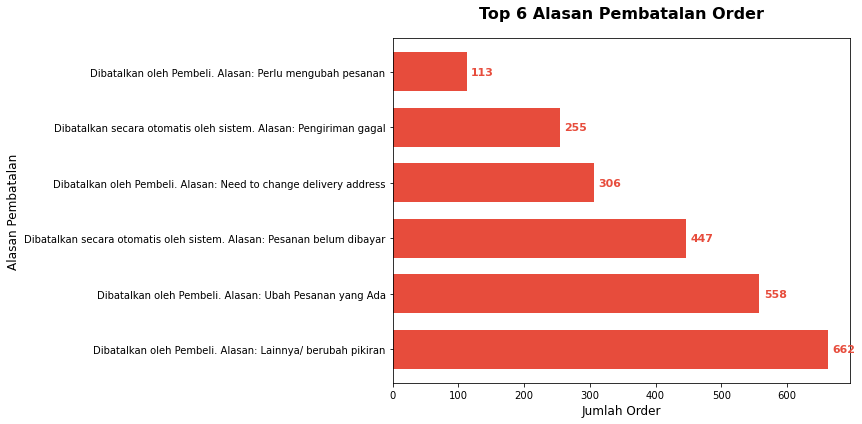

In [18]:
# Grafik penyebab pembatalan pemesanan
cancellation_counts = df[df['cancellation'] != 'Not Cancelled']['cancellation'].value_counts().head(6)

# Buat horizontal bar chart
plt.figure(figsize=(12, 6))
ax = cancellation_counts.plot(kind='barh', color='#E74C3C', width=0.7)

# Tambahkan label nilai di samping bar
for i, (idx, value) in enumerate(cancellation_counts.items()):
    ax.text(value + (cancellation_counts.max() * 0.01), i, f'{value:,}', 
            ha='left', va='center', fontweight='bold', fontsize=11, color='#E74C3C')

# Format sumbu x dengan pemisah ribuan
ax.xaxis.set_major_formatter(lambda x, p: f'{int(x):,}')

plt.title('Top 6 Alasan Pembatalan Order', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Jumlah Order', fontsize=12)
plt.ylabel('Alasan Pembatalan', fontsize=12)

# Layout rapi
plt.tight_layout()
plt.show()

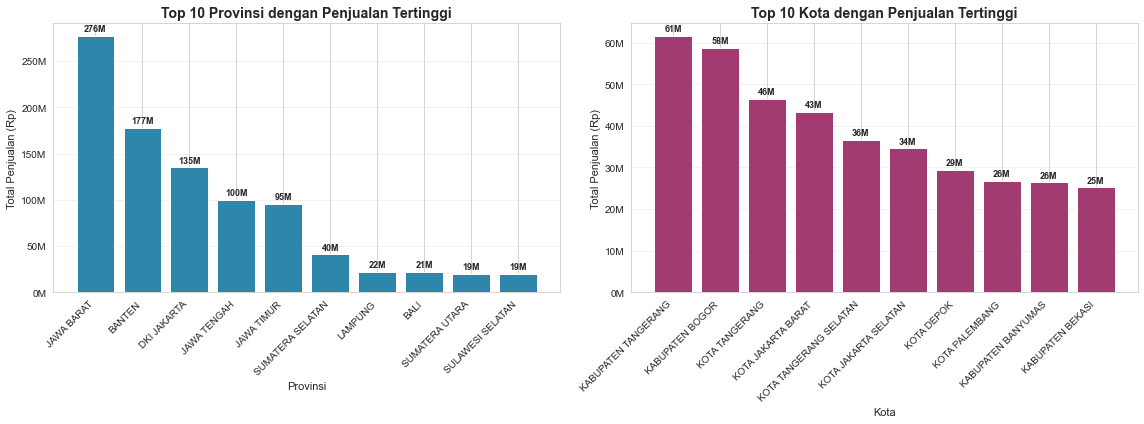

In [19]:
# Buat grafik 10 province dan kota dengan penjualan terbanyak
sns.set_style('whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top_provinces = df.groupby('province')['total_payment'].sum().sort_values(ascending=False).head(10)
ax1.bar(range(len(top_provinces)), top_provinces.values, color='#2E86AB')
ax1.yaxis.set_major_formatter(lambda x, p: f'{int(x/1e6)}M')

for i, v in enumerate(top_provinces.values):
    ax1.text(i, v + (top_provinces.max() * 0.01), f'{int(v/1e6)}M', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_title('Top 10 Provinsi dengan Penjualan Tertinggi', fontsize=14, fontweight='bold')
ax1.set_xlabel('Provinsi', fontsize=11)
ax1.set_ylabel('Total Penjualan (Rp)', fontsize=11)
ax1.set_xticks(range(len(top_provinces.index)))
ax1.set_xticklabels(top_provinces.index, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)


top_cities = df.groupby('city')['total_payment'].sum().sort_values(ascending=False).head(10)
ax2.bar(range(len(top_cities)), top_cities.values, color='#A23B72')

ax2.yaxis.set_major_formatter(lambda x, p: f'{int(x/1e6)}M')

for i, v in enumerate(top_cities.values):
    ax2.text(i, v + (top_cities.max() * 0.01), f'{int(v/1e6)}M', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Top 10 Kota dengan Penjualan Tertinggi', fontsize=14, fontweight='bold')
ax2.set_xlabel('Kota', fontsize=11)
ax2.set_ylabel('Total Penjualan (Rp)', fontsize=11)
ax2.set_xticks(range(len(top_cities.index)))
ax2.set_xticklabels(top_cities.index, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()

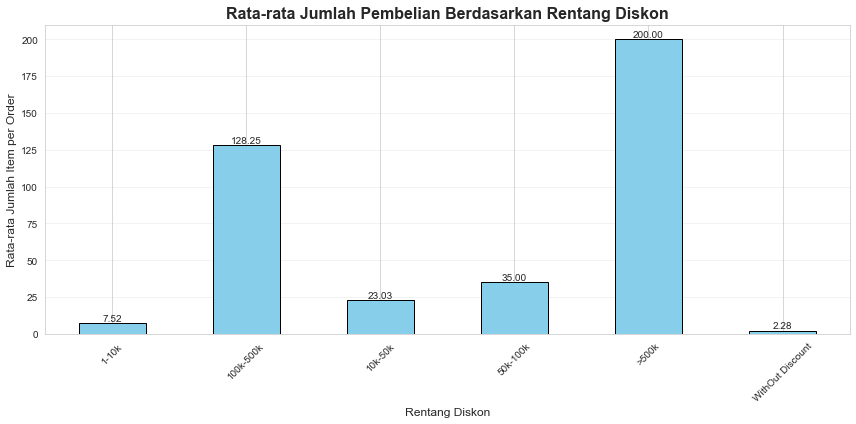

In [20]:
# 3. Rata-rata jumlah penjualan berdasarkan rentang diskon
sns.set_style('whitegrid')
plt.figure(figsize=(12,6))

# Hitung rata-rata qty per rentang diskon
avg_qty_by_discount = df.groupby('discount_segment')['total_qty'].mean()

# Plot
avg_qty_by_discount.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Rata-rata Jumlah Pembelian Berdasarkan Rentang Diskon', fontsize=16, fontweight='bold')
plt.xlabel('Rentang Diskon', fontsize=12)
plt.ylabel('Rata-rata Jumlah Item per Order', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Tambahkan nilai di atas bar
for i, v in enumerate(avg_qty_by_discount):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

<Figure size 864x432 with 0 Axes>

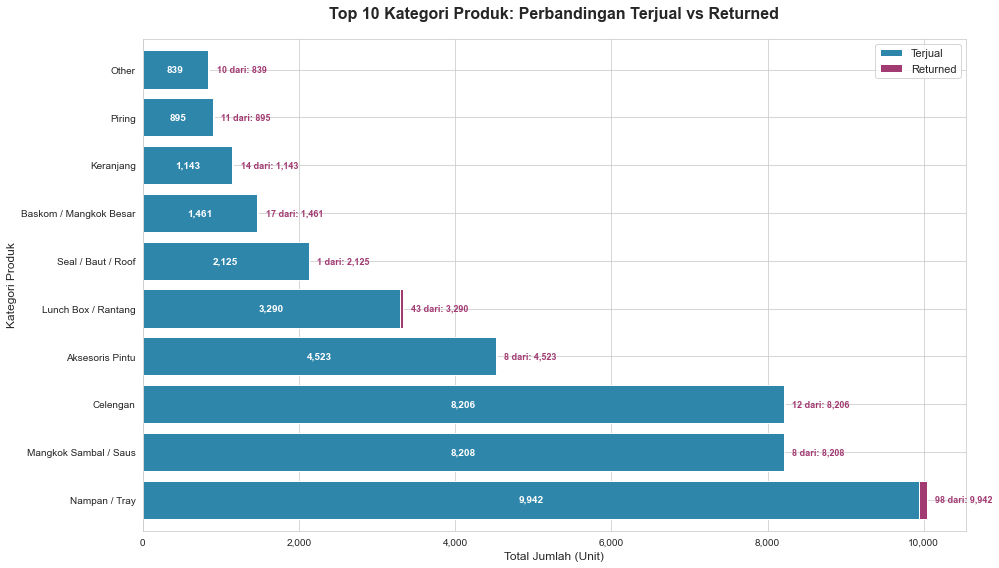

In [21]:
# 4.Buat grafik jumlah penjualan vs jumlah dikembalikan suatu produk

sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))

# Ambil top 10 kategori berdasarkan total_qty
top_products = df.groupby('product_categories')[['total_qty', 'total_returned_qty']].sum().sort_values('total_qty', ascending=False).head(10)

# Buat stacked bar
ax = top_products[['total_qty', 'total_returned_qty']].plot(
    kind='barh', 
    stacked=True,
    color=['#2E86AB', '#A23B72'],  # Biru untuk terjual, Ungu untuk returned
    figsize=(14, 8),
    width=0.8
)

# Menambahkan label nilai
for i, (idx, row) in enumerate(top_products.iterrows()):
    total = row['total_qty'] + row['total_returned_qty']
    
    # Label untuk total_qty (biru) - tetap di tengah bagian biru
    if row['total_qty'] > 0:
        ax.text(row['total_qty']/2, i, f'{int(row["total_qty"]):,}', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    
    # Label untuk total_returned_qty dengan format sederhana: "returned dari: total"
    if row['total_returned_qty'] > 0:
        x_pos = row['total_qty'] + row['total_returned_qty'] + (top_products['total_qty'].max() * 0.01)
        ax.text(x_pos, i, f'{int(row["total_returned_qty"]):,} dari: {int(row["total_qty"]):,}', 
                ha='left', va='center', color='#A23B72', fontweight='bold', fontsize=9)

plt.legend(['Terjual', 'Returned'], fontsize=11)
ax.xaxis.set_major_formatter(lambda x, p: f'{int(x):,}')

plt.title('Top 10 Kategori Produk: Perbandingan Terjual vs Returned', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Jumlah (Unit)', fontsize=12)
plt.ylabel('Kategori Produk', fontsize=12)

# Layout rapi
plt.tight_layout()
plt.show()

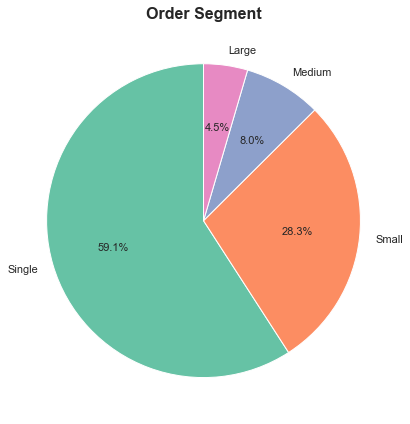

Segmen 'Large' memiliki rata-rata jumlah pembelian: 21.14 unit
Segmen 'Medium' memiliki rata-rata jumlah pembelian: 4.74 unit
Segmen 'Single' memiliki rata-rata jumlah pembelian: 1.00 unit
Segmen 'Small' memiliki rata-rata jumlah pembelian: 2.23 unit


In [22]:
# 6. Distribusi jumlah pesanan (Pie Chart)
plt.figure(figsize=(12,6))

order_segments = df['order_segment'].value_counts()
colors = sns.color_palette('Set2', n_colors=len(order_segments))
plt.pie(order_segments.values, labels=order_segments.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, textprops={'fontsize': 11})
plt.title('Order Segment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# tampilkan rata-rata pembelian tiap segmen
avg_qty_per_segment = df.groupby('order_segment')['total_qty'].mean().round(2)
for segment, avg_qty in avg_qty_per_segment.items():
    print(f"Segmen '{segment}' memiliki rata-rata jumlah pembelian: {avg_qty:,.2f} unit")

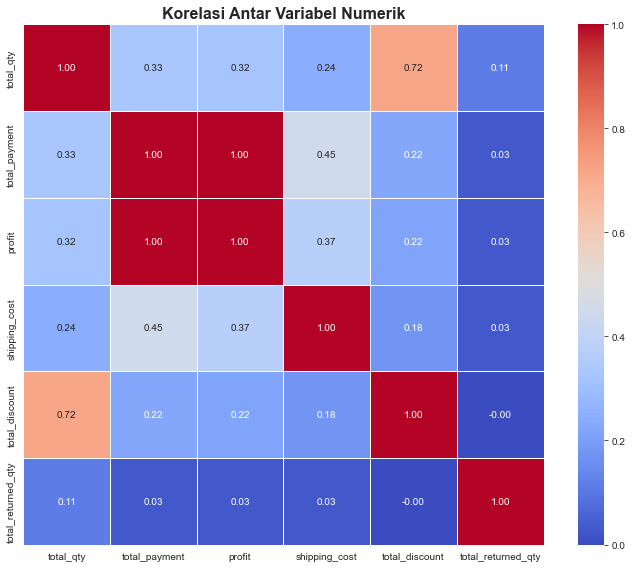

In [23]:
# Heatmap untuk melihat hubungan antar variabel (total_qty, total_payment, profit, shipping_cost, total_discount, total_returned_qty)

plt.figure(figsize=(10, 8))

# Pilih kolom numerik yang relevan
numerical_cols = ['total_qty', 'total_payment', 'profit', 'shipping_cost', 
                  'total_discount', 'total_returned_qty']

correlation = df[numerical_cols].corr()

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)

plt.title('Korelasi Antar Variabel Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()